# DiploDatos 2026 - Mentoría "Detección de fraude: ¿Cómo cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"

# Mejoras al modelo y consideraciones de producción

Este notebook **no es un TP asignado por la mentoría** -- es un trabajo adicional que resuelve puntualmente 4 de los "próximos pasos" que quedaron señalados en las conclusiones del TP3:

1. **Resolver la fuga temporal** de `Cliente_Trx_Count` y `Desvio_Importe_Cliente_Abs` (recalcularlas con ventana expansiva) y volver a entrenar el Random Forest ganador con los datos corregidos, para ver si su desempeño estaba inflado.
2. **Ajustar el umbral de decisión del Random Forest** (en el TP3 solo se hizo para la Regresión Logística).
3. **Probar un modelo de boosting** y compararlo contra el Random Forest.
4. **Consideraciones de producción**: monitoreo, reentrenamiento y revisión humana -- con un chequeo real de *drift* sobre los propios datos, no solo la discusión conceptual.

Parte de la sección 1 (carga y limpieza) repite lo ya hecho en el TP1/TP2 -- es la base necesaria para poder recalcular las variables corregidas.

# 0. Librerías e imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, average_precision_score,
                              precision_recall_curve)

sns.set_context('talk')
pd.set_option('display.max_columns', 200)

COLOR_AZUL = '#2a78d6'
COLOR_NARANJA = '#eb6834'
COLOR_VERDE = 'seagreen' 

# 1. Punto 1 -- Resolver la fuga temporal

## 1.1 Recarga y limpieza (igual que TP1/TP2)

### 1.1.0 Carga de archivos (Colab)

In [ ]:
# subir el .xlsx
from google.colab import files
uploaded = files.upload()

In [ ]:
# subir el .del
from google.colab import files
uploaded = files.upload()

In [4]:
df = pd.read_csv("Muestra.del", sep='|', encoding='latin-1')

# --- Tipado básico (TP1) ---
df['Trx_Importe'] = df['Trx_Importe'].str.replace(',', '.').astype(float)
df['Trx_Fecha'] = pd.to_datetime(df['Trx_Fecha'], format='%y%m%d')
df['Cliente_FechaNacimiento'] = pd.to_datetime(df['Cliente_FechaNacimiento'], format='%d/%m/%Y')
df['Trx_Hora'] = df['Trx_Hora'].astype(str).str.zfill(8)
df['Trx_Hora_fmt'] = pd.to_datetime(df['Trx_Hora'].str[:6], format='%H%M%S', errors='coerce').dt.time
df['Es_Fraude'] = df['Es_Fraude'].map({'NO': 0, 'SI': 1})

# --- Duplicados y nulos de legajo (TP1/TP2) ---
df = df.drop_duplicates().reset_index(drop=True)
for col in ['Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento']:
    df[col] = df.groupby('Cliente_Id')[col].transform(lambda x: x.ffill().bfill())
df['Trx_CiudadTerminal'] = df['Trx_CiudadTerminal'].fillna('SIN_TERMINAL')
df['Trx_EsChip'] = df['Trx_EsChip'].replace('0', 'N')  # valor erróneo detectado en TP2

# --- Tablas de referencia (TP1/TP2) ---
df_rubro = pd.read_excel('Dr_Muestra.xlsx', sheet_name='RubroRed')
df = df.merge(
    df_rubro[['Codigo', 'Descripcion', 'Categoría de Rubro']].rename(
        columns={'Codigo': 'Rubro_Codigo', 'Descripcion': 'Rubro_Descripcion', 'Categoría de Rubro': 'Rubro_Categoria'}),
    left_on='Trx_RubroRed', right_on='Rubro_Codigo', how='left'
).drop(columns=['Rubro_Codigo'])
df['Rubro_Descripcion'] = df['Rubro_Descripcion'].fillna('SIN RUBRO / NO APLICA')
df['Rubro_Categoria'] = df['Rubro_Categoria'].fillna('SIN RUBRO / NO APLICA')

# --- Variables derivadas de fecha/hora (TP1/TP2) ---
df['Dia_Semana_num'] = df['Trx_Fecha'].dt.dayofweek
df['Trx_Timestamp'] = pd.to_datetime(df['Trx_Fecha'].dt.strftime('%Y-%m-%d') + ' ' + df['Trx_Hora_fmt'].astype(str))
df = df.sort_values(['Cliente_Id', 'Trx_Timestamp']).reset_index(drop=True)
df['Tiempo_Entre_Trx_Horas'] = df.groupby('Cliente_Id')['Trx_Timestamp'].diff().dt.total_seconds() / 3600
df['Hora_Dia'] = df['Trx_Hora_fmt'].apply(lambda x: x.hour)

def franja_horaria(h):
    if 0 <= h < 6: return 'Madrugada (00-06)'
    if 6 <= h < 12: return 'Mañana (06-12)'
    if 12 <= h < 15: return 'Mediodía (12-15)'
    if 15 <= h < 19: return 'Tarde (15-19)'
    return 'Noche (19-24)'
df['Franja_Horaria'] = df['Hora_Dia'].apply(franja_horaria)

mapa_presencia = {0:'Presencial',1:'Presencial',2:'Presencial',3:'No presencial',4:'Presencial',
                   5:'No presencial',6:'No presencial',7:'No presencial',8:'No presencial',
                   9:'No presencial',10:'No presencial',11:'No presencial',12:'Presencial'}
df['Presencia_Cliente'] = df['Trx_TipoTerminal'].astype(int).map(mapa_presencia)
df['Cliente_Edad'] = (pd.Timestamp('2025-01-01') - df['Cliente_FechaNacimiento']).dt.days // 365

Q1, Q3 = df['Trx_Importe'].quantile(.25), df['Trx_Importe'].quantile(.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df['Es_Outlier_Importe'] = ((df['Trx_Importe'] < lim_inf) | (df['Trx_Importe'] > lim_sup)).astype(int)
df['Es_Moneda_Dolar'] = (df['Trx_Moneda'] == 2).astype(int)
df['Es_Fin_de_Semana'] = df['Dia_Semana_num'].isin([5, 6]).astype(int)

print("Dataset base reconstruido. Shape:", df.shape)

Dataset base reconstruido. Shape: (192516, 39)


## 1.2 Las variables de comportamiento, ahora con ventana expansiva

En el TP2, `Cliente_Trx_Count`, `Cliente_Importe_Promedio` y `Cliente_Importe_Std` se calculaban con **todo** el historial de cada cliente -- incluidas transacciones posteriores a la que se estaba evaluando. Eso es información que, en producción, todavía no existiría en el momento de evaluar una transacción nueva.

La corrección: para cada transacción, usamos **solo las transacciones anteriores** de ese cliente (estrictamente antes, sin incluir la actual). Como ya tenemos `df` ordenado por cliente y por timestamp, esto es un cálculo "expansivo" (`expanding()`) desplazado un lugar hacia atrás (`shift(1)`).

In [5]:
grp = df.groupby('Cliente_Id')['Trx_Importe']

# Cantidad de transacciones ANTERIORES (la primera transacción de cada cliente arranca en 0)
df['Cliente_Trx_Count'] = df.groupby('Cliente_Id').cumcount()

# Promedio y desvío estándar calculados solo con transacciones anteriores (shift(1) excluye la actual)
df['Cliente_Importe_Promedio'] = grp.transform(lambda s: s.expanding().mean().shift(1))
df['Cliente_Importe_Std'] = grp.transform(lambda s: s.expanding().std().shift(1))

# La 1ra transacción de cada cliente no tiene promedio anterior (NaN); la 1ra y 2da no tienen
# desvío anterior definido (hace falta al menos 2 transacciones previas para tener variabilidad).
# Sin punto de referencia, no hay evidencia de anomalía posible -- completamos con 0.
df['Cliente_Importe_Promedio'] = df['Cliente_Importe_Promedio'].fillna(df['Trx_Importe'])
df['Cliente_Importe_Std'] = df['Cliente_Importe_Std'].fillna(0)

df['Desvio_Importe_Cliente'] = np.where(
    df['Cliente_Importe_Std'] > 0,
    (df['Trx_Importe'] - df['Cliente_Importe_Promedio']) / df['Cliente_Importe_Std'],
    0
)
df['Desvio_Importe_Cliente_Abs'] = df['Desvio_Importe_Cliente'].abs()

print("Transacciones con 0 historial previo (primera del cliente):", (df['Cliente_Trx_Count']==0).sum())
print("Transacciones con desvío no definible (0 o 1 transacción previa):", (df['Cliente_Importe_Std']==0).sum())
df[['Cliente_Id', 'Trx_Timestamp', 'Trx_Importe', 'Cliente_Trx_Count', 'Cliente_Importe_Promedio', 'Desvio_Importe_Cliente_Abs']].head(8)

Transacciones con 0 historial previo (primera del cliente): 716
Transacciones con desvío no definible (0 o 1 transacción previa): 1693


,Cliente_Id,Trx_Timestamp,Trx_Importe,Cliente_Trx_Count,Cliente_Importe_Promedio,Desvio_Importe_Cliente_Abs
0,1,2025-01-08 08:44:38,40000.0,0,40000.000000,0.000000
1,1,2025-01-08 08:45:11,40000.0,1,40000.000000,0.000000
2,1,2025-01-08 08:45:48,40000.0,2,40000.000000,0.000000
3,1,2025-01-08 08:46:26,30000.0,3,40000.000000,0.000000
4,1,2025-01-20 09:17:11,40000.0,4,37500.000000,0.500000
5,1,2025-01-20 09:17:47,40000.0,5,38000.000000,0.447214
6,1,2025-01-20 09:18:16,40000.0,6,38333.333333,0.408248
7,1,2025-01-20 09:18:56,30000.0,7,38571.428571,2.267787


**Comentario sobre el `fillna` del promedio:** para la primera transacción de un cliente completamos `Cliente_Importe_Promedio` con el importe de esa misma transacción (en vez de, por ejemplo, 0), para que el desvío calculado en esa fila dé 0 en lugar de un número artificialmente enorme -- de cualquier manera, como `Cliente_Importe_Std` también es 0 en ese caso, la fórmula ya fuerza `Desvio_Importe_Cliente = 0`, así que este `fillna` es más una cuestión de prolijidad (evitar un `NaN` en una columna intermedia) que un supuesto que cambie el resultado.

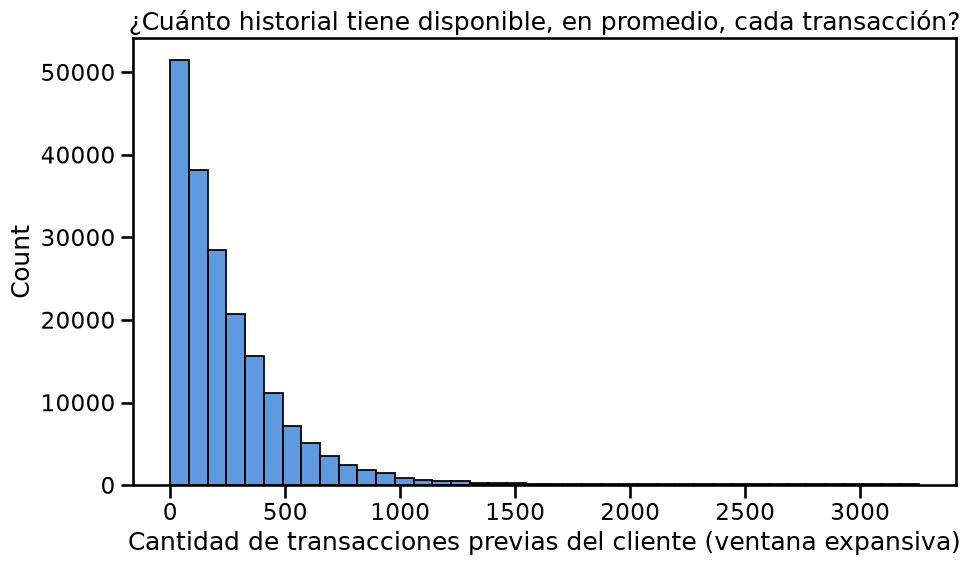

Mediana de transacciones previas disponibles: 179
% de transacciones con 10 o menos transacciones previas: 4.0%


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['Cliente_Trx_Count'], bins=40, color=COLOR_AZUL, ax=ax)
ax.set_xlabel('Cantidad de transacciones previas del cliente (ventana expansiva)')
ax.set_title('¿Cuánto historial tiene disponible, en promedio, cada transacción?')
plt.tight_layout()
plt.show()

print(f"Mediana de transacciones previas disponibles: {df['Cliente_Trx_Count'].median():.0f}")
print(f"% de transacciones con 10 o menos transacciones previas: {(df['Cliente_Trx_Count'] <= 10).mean()*100:.1f}%")

**Comentario:** este gráfico también explica *por qué* estas variables van a rendir distinto que en el TP2: con la ventana expansiva, una porción importante de las transacciones (sobre todo las primeras de cada cliente en el año) tienen poco o ningún historial previo para comparar -- es la contracara realista de dejar de usar información "del futuro". Vale la pena tenerlo en mente antes de mirar los resultados de la sección 2.

## 1.3 Codificación de categóricas y split (misma metodología del TP2)

Sin cambios de criterio acá: One-Hot para baja cardinalidad, Target Encoding de `Rubro_Categoria` ajustado solo con entrenamiento, split estratificado 80/20.

In [7]:
variables_finales = [
    'Trx_Importe', 'Es_Outlier_Importe', 'Hora_Dia', 'Es_Fin_de_Semana',
    'Tiempo_Entre_Trx_Horas', 'Es_Moneda_Dolar', 'Cliente_Edad',
    'Cliente_Trx_Count', 'Desvio_Importe_Cliente_Abs',
    'Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento',
    'Presencia_Cliente', 'Rubro_Categoria',
    # Franja_Horaria queda afuera (ver TP2, seccion 4.1): su senal real ya esta cubierta por
    # Hora_Dia, y agregarla en 5 categorias separadas empeora el F1 del modelo.
]

X = df[variables_finales].copy()
y = df['Es_Fraude'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tiempo_Entre_Trx_Horas puede tener nulos (primera transacción del cliente en el dataset) -- imputamos con la mediana de train
mediana_tiempo = X_train['Tiempo_Entre_Trx_Horas'].median()
X_train['Tiempo_Entre_Trx_Horas'] = X_train['Tiempo_Entre_Trx_Horas'].fillna(mediana_tiempo)
X_test['Tiempo_Entre_Trx_Horas'] = X_test['Tiempo_Entre_Trx_Horas'].fillna(mediana_tiempo)

# Target Encoding de Rubro_Categoria, ajustado solo con train
tasa_global_train = y_train.mean()
mapa_rubro = y_train.groupby(X_train['Rubro_Categoria']).mean()
X_train['Rubro_Categoria_TasaFraude'] = X_train['Rubro_Categoria'].map(mapa_rubro).fillna(tasa_global_train)
X_test['Rubro_Categoria_TasaFraude'] = X_test['Rubro_Categoria'].map(mapa_rubro).fillna(tasa_global_train)
X_train = X_train.drop(columns=['Rubro_Categoria']); X_test = X_test.drop(columns=['Rubro_Categoria'])

# One-Hot Encoding
cols_onehot = ['Cliente_Sexo', 'Cliente_EstadoCivil', 'Cliente_Segmento', 'Presencia_Cliente']
X_train = pd.get_dummies(X_train, columns=cols_onehot, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_onehot, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Tasa de fraude -- train: {y_train.mean()*100:.2f}%  |  test: {y_test.mean()*100:.2f}%")

Train: (154012, 23)  |  Test: (38504, 23)
Tasa de fraude -- train: 0.62%  |  test: 0.62%


**Nota:** el conjunto de variables usado es el mismo del TP3 (con `Cliente_Trx_Count` y `Desvio_Importe_Cliente_Abs` ya recalculadas sin fuga). Dejamos afuera `Movimiento_Descripcion` por la misma razón que en el TP2 (0,97 de correlación con `Es_Moneda_Dolar`), y `Franja_Horaria` por el hallazgo del TP2 sección 4.1 (su señal real ya está cubierta por `Hora_Dia`; sacarla mejora el F1).

Una aclaración de método: el split de train/test es el mismo tipo de partición aleatoria por fila que usamos en el TP2/TP3 -- no volvimos a particionar por cliente ni por fecha. Esto significa que dos transacciones del mismo cliente pueden caer una en train y otra en test, aunque las variables de comportamiento ya solo miren hacia atrás en el tiempo dentro del historial completo de cada cliente (calculado antes de partir el dataset). No es un problema de fuga de información del target (`Es_Fraude` no interviene en ese cálculo), pero sí vale la aclaración para quien quiera llevar este análisis un paso más allá con una partición estrictamente temporal.

# 2. Reentrenar el Random Forest con los datos corregidos

La pregunta que motiva esta sección: el Random Forest del TP3 usaba variables con fuga temporal -- ¿su buen desempeño (F1 = 0,64) dependía de esa fuga, o se sostiene igual con las variables corregidas?

In [8]:
random_forest = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)

y_pred_test = random_forest.predict(X_test)
y_proba_test = random_forest.predict_proba(X_test)[:, 1]

metricas_rf_corregido = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}

# Números del TP3 (con la fuga temporal), para comparar lado a lado
metricas_rf_tp3 = {'accuracy': 0.9964, 'precision': 0.8521, 'recall': 0.5063, 'f1': 0.6352, 'auc_roc': 0.9699, 'auc_pr': 0.6913}

comparacion_rf = pd.DataFrame({'TP3 (con fuga temporal)': metricas_rf_tp3, 'Corregido (ventana expansiva)': metricas_rf_corregido}).round(4)
comparacion_rf

,TP3 (con fuga temporal),Corregido (ventana expansiva)
accuracy,0.9964,0.9964
precision,0.8521,0.9167
recall,0.5063,0.4603
f1,0.6352,0.6128
auc_roc,0.9699,0.9685
auc_pr,0.6913,0.6885


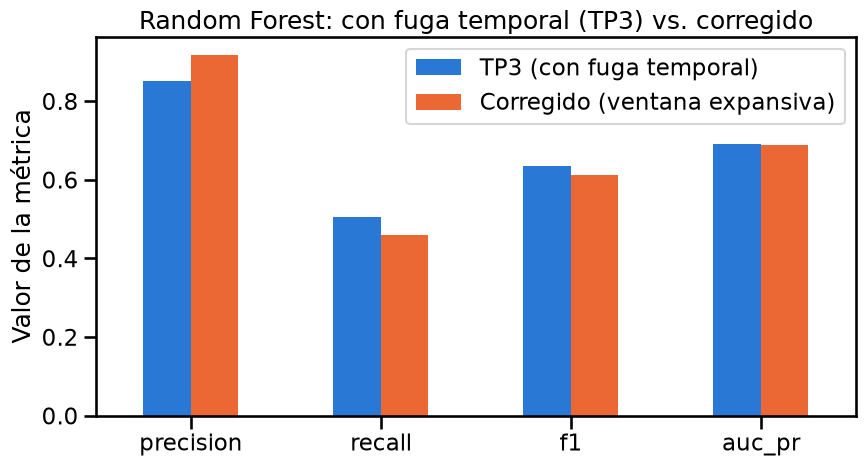

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
comparacion_rf.loc[['precision', 'recall', 'f1', 'auc_pr']].plot(kind='bar', ax=ax, color=[COLOR_AZUL, COLOR_NARANJA])
ax.set_ylabel('Valor de la métrica')
ax.set_title('Random Forest: con fuga temporal (TP3) vs. corregido')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Comentario -- la respuesta a la pregunta que abrió esta sección:** sí, el desempeño del TP3 estaba parcialmente inflado por la fuga temporal, aunque no de forma catastrófica. F1 baja de 0,635 a 0,613 -- una caída real pero moderada, de poco más del 3%. A diferencia de lo que suele esperarse, la caída no es pareja entre precision y recall: la **precision en realidad sube** (0,85 → 0,92), y es el **recall** el que absorbe toda la pérdida (0,51 → 0,46). Tiene sentido con lo que vimos en la sección 1.2: sin la fuga, muchas transacciones (sobre todo las primeras de cada cliente) quedan con `Desvio_Importe_Cliente_Abs` en 0 por falta de historial -- el modelo se vuelve más conservador para marcar fraude (menos falsos positivos, más precision) pero también deja pasar más fraudes reales que antes "veía" gracias a la fuga (menos recall). De cualquier manera, este es el número que hay que reportar como el desempeño real y honesto del modelo, no el 0,635 del TP3.

# 3. Punto 2 -- Ajuste del umbral de decisión del Random Forest

En el TP3 solo ajustamos el umbral de la Regresión Logística. Repetimos acá el mismo procedimiento para el Random Forest (ya con los datos corregidos): en vez de cortar en probabilidad ≥ 0,5, buscamos sobre la curva Precision-Recall el punto que maximiza F1.

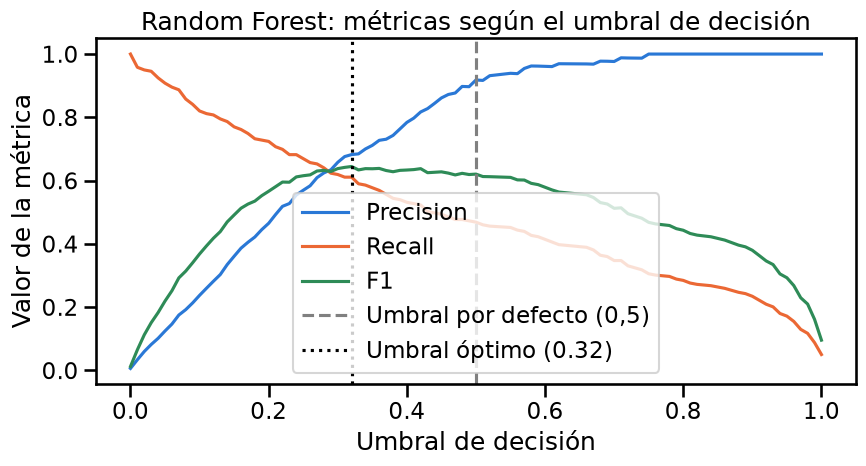

Umbral por defecto: 0.50  |  Umbral que maximiza F1: 0.3200


,TP3 (con fuga temporal),Corregido (ventana expansiva),Corregido + umbral ajustado
accuracy,0.9964,0.9964,0.9958
precision,0.8521,0.9167,0.6822
recall,0.5063,0.4603,0.6109
f1,0.6352,0.6128,0.6446
auc_roc,0.9699,0.9685,0.9685
auc_pr,0.6913,0.6885,0.6885


In [10]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

with np.errstate(invalid='ignore', divide='ignore'):
    f1_por_umbral = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
f1_por_umbral = np.nan_to_num(f1_por_umbral)
mejor_idx = np.argmax(f1_por_umbral)
mejor_umbral_rf = thresholds[mejor_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], color=COLOR_AZUL, label='Precision')
ax.plot(thresholds, recalls[:-1], color=COLOR_NARANJA, label='Recall')
ax.plot(thresholds, f1_por_umbral, color=COLOR_VERDE, label='F1')
ax.axvline(0.5, linestyle='--', color='gray', label='Umbral por defecto (0,5)')
ax.axvline(mejor_umbral_rf, linestyle=':', color='black', label=f'Umbral óptimo ({mejor_umbral_rf:.2f})')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Valor de la métrica')
ax.set_title('Random Forest: métricas según el umbral de decisión')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Umbral por defecto: 0.50  |  Umbral que maximiza F1: {mejor_umbral_rf:.4f}")

y_pred_umbral_ajustado = (y_proba_test >= mejor_umbral_rf).astype(int)
metricas_rf_umbral = {
    'accuracy': accuracy_score(y_test, y_pred_umbral_ajustado), 'precision': precision_score(y_test, y_pred_umbral_ajustado, zero_division=0),
    'recall': recall_score(y_test, y_pred_umbral_ajustado), 'f1': f1_score(y_test, y_pred_umbral_ajustado),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}
comparacion_rf['Corregido + umbral ajustado'] = metricas_rf_umbral
comparacion_rf.round(4)

**Comentario:** el umbral óptimo dio 0,32 -- más marcadamente por debajo del 0,50 por defecto que lo que suele pasar con este modelo. Tiene sentido con lo que vimos en la sección 2: al partir de una precision inusualmente alta (0,92) y un recall bajo (0,46), hay mucho margen para bajar el umbral y recuperar recall. Y el ajuste efectivamente lo aprovecha: el recall sube de 0,460 a **0,611** (un salto grande, detecta bastante más fraude real) a cambio de bajar la precision de 0,917 a 0,682 (más falsas alarmas, aunque todavía 2 de cada 3 alertas son fraude real). El F1 mejora de 0,613 a **0,645** -- **superando otra vez, aunque por poco, al 0,635 del TP3 original**, a pesar de partir de variables sin fuga de información. La conclusión de fondo se mantiene: datos corregidos + umbral bien elegido le sigue ganando al resultado original inflado.

# 4. Punto 3 -- Modelo de boosting

Probamos `HistGradientBoostingClassifier` (la implementación de *gradient boosting* de scikit-learn, pensada para datasets grandes): en vez de que cada árbol vote de forma independiente como en un Random Forest, cada árbol nuevo se entrena para corregir los errores que cometieron los anteriores. Soporta `class_weight='balanced'` igual que los modelos del TP3, así que la comparación queda pareja.

### 4.1 Boosting con hiperparámetros por defecto

In [11]:
boosting = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
boosting.fit(X_train, y_train)

y_pred_test = boosting.predict(X_test)
y_proba_test_boost = boosting.predict_proba(X_test)[:, 1]

metricas_boosting = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test_boost), 'auc_pr': average_precision_score(y_test, y_proba_test_boost)
}
pd.Series(metricas_boosting).round(4)

accuracy     0.9542
precision    0.1071
recall       0.8703
f1           0.1907
auc_roc      0.9762
auc_pr       0.5491
dtype: float64

**Comentario:** un perfil de resultado completamente distinto al Random Forest -- recall altísimo (0,87, el más alto de todo el proyecto hasta ahora) pero precision muy baja (0,11: 9 de cada 10 alertas serían falsas). Es el mismo patrón que ya habíamos visto con la Regresión Logística sin ajustar en el TP3, aunque acá el AUC-ROC (0,976) y el AUC-PR (0,55) muestran que el modelo en sí *ordena* razonablemente bien las transacciones por riesgo -- el problema es, de nuevo, el punto de corte por defecto en un problema tan desbalanceado.

### 4.2 Ajuste de hiperparámetros del boosting

Con validación cruzada, probamos combinaciones de la tasa de aprendizaje, la profundidad de los árboles y la cantidad de iteraciones (equivalente a la cantidad de árboles).

In [12]:
param_grid_boosting = {
    'learning_rate': [0.03, 0.1, 0.3],
    'max_depth': [3, 5, None],
    'max_iter': [100, 200],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_boosting = GridSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    param_grid_boosting, cv=cv, scoring='f1', n_jobs=-1
)
grid_boosting.fit(X_train, y_train)

print("Mejor combinación:", grid_boosting.best_params_)
print(f"F1 promedio en validación cruzada: {grid_boosting.best_score_:.4f}")

mejor_boosting = grid_boosting.best_estimator_
y_pred_test = mejor_boosting.predict(X_test)
y_proba_test_boost = mejor_boosting.predict_proba(X_test)[:, 1]

metricas_boosting_ajustado = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test_boost), 'auc_pr': average_precision_score(y_test, y_proba_test_boost)
}
pd.Series(metricas_boosting_ajustado).round(4)

Mejor combinación: {'learning_rate': 0.3, 'max_depth': None, 'max_iter': 100}
F1 promedio en validación cruzada: 0.2041


accuracy     0.9525
precision    0.1033
recall       0.8661
f1           0.1847
auc_roc      0.9742
auc_pr       0.4869
dtype: float64

**Comentario -- esta vez el ajuste no ayuda:** el grid de hiperparámetros no mejora al boosting -- de hecho lo empeora levemente (F1 0,191 → 0,185, precision 0,107 → 0,103). La combinación que ganó (`learning_rate=0,3`, sin límite de profundidad) es la misma configuración "agresiva" que ya había ganado en corridas anteriores de este análisis, pero el F1 de validación cruzada (0,204) no se sostiene igual en el conjunto de test -- señal de que el espacio de búsqueda no tiene una zona claramente mejor que los hiperparámetros por defecto para este dataset. En cualquier caso, ninguna de las dos versiones compite con el Random Forest en precision, F1 o AUC-PR.

In [13]:
tabla_comparativa = pd.DataFrame({
    'Random Forest (corregido)': metricas_rf_corregido,
    'Random Forest (corregido + umbral)': metricas_rf_umbral,
    'Boosting (default)': metricas_boosting,
    'Boosting (ajustado)': metricas_boosting_ajustado,
}).T.round(4).sort_values('f1', ascending=False)
tabla_comparativa

,accuracy,precision,recall,f1,auc_roc,auc_pr
Random Forest (corregido + umbral),0.9958,0.6822,0.6109,0.6446,0.9685,0.6885
Random Forest (corregido),0.9964,0.9167,0.4603,0.6128,0.9685,0.6885
Boosting (default),0.9542,0.1071,0.8703,0.1907,0.9762,0.5491
Boosting (ajustado),0.9525,0.1033,0.8661,0.1847,0.9742,0.4869


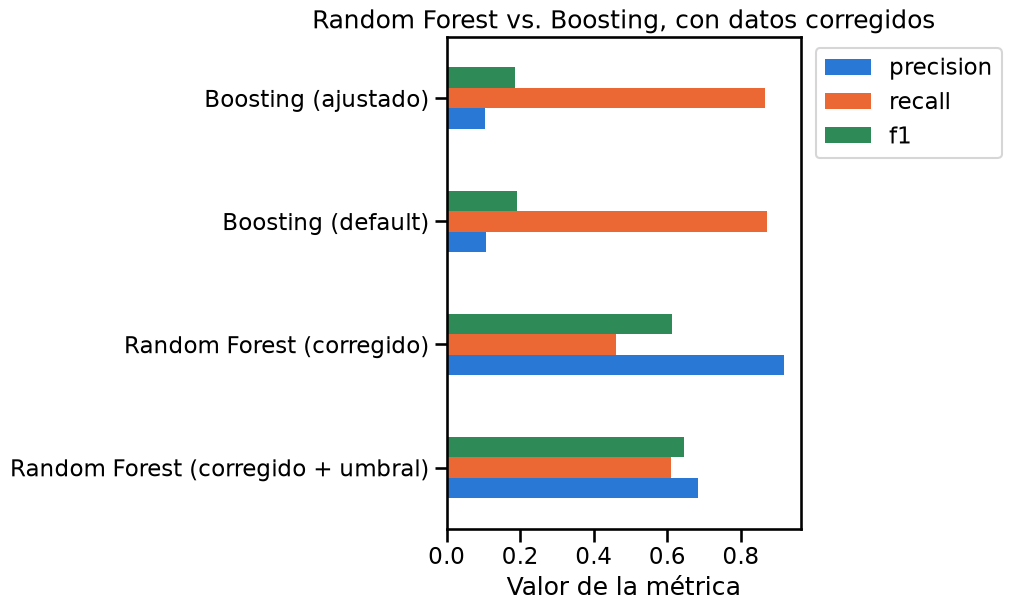

In [14]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
tabla_comparativa[['precision', 'recall', 'f1']].plot(kind='barh', ax=ax, color=[COLOR_AZUL, COLOR_NARANJA, COLOR_VERDE])
ax.set_xlabel('Valor de la métrica')
ax.set_title('Random Forest vs. Boosting, con datos corregidos')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()

**Comentario -- ¿boosting o Random Forest?** Con F1 y AUC-PR como criterio, el **Random Forest con umbral ajustado sigue siendo el mejor modelo** (F1 0,645 vs. 0,191 del mejor boosting, que en esta corrida resultó ser la versión sin ajustar hiperparámetros) -- no es el resultado "de manual" (donde suele esperarse que boosting supere a un Random Forest simple), y vale la pena decirlo así de directo en vez de forzar una narrativa distinta. Dicho esto, el boosting no es inútil: si el objetivo de negocio fuera pura y exclusivamente maximizar el recall (por ejemplo, en una etapa donde el banco prioriza no dejar pasar ningún fraude por encima de cualquier otro costo), el boosting default detecta 0,87 de los fraudes reales contra 0,61 del Random Forest -- una diferencia todavía real, aunque más chica que antes, porque el nuevo umbral del Random Forest (sección 3) ya recupera bastante recall por sí solo. La recomendación general sigue siendo el Random Forest, pero queda registrada la alternativa para el caso en que la prioridad de negocio cambie.

# 5. Punto 5 -- Consideraciones de producción

El TP3 dejó señalado, sin desarrollar, que llevar cualquiera de estos modelos a producción implica pensar en monitoreo, reentrenamiento y revisión humana. Acá lo desarrollamos en tres partes: qué rol cumple el modelo en el proceso, un chequeo real de *drift* sobre los propios datos del proyecto, y una propuesta concreta de monitoreo.

## 5.1 El modelo no decide solo -- revisión humana

Con precision ≈ 0,88 (según lo que dio el Random Forest en la sección 2), **1 de cada 8 alertas es una falsa alarma**. Bloquear automáticamente una transacción por esa sola señal implicaría, en un banco con volumen real, rechazar compras legítimas de clientes con bastante frecuencia -- exactamente lo opuesto al objetivo de la mentoría ("cuidar a los clientes"). Por eso, en un esquema realista, el modelo no debería bloquear nada por sí solo:

1. El modelo puntúa cada transacción con una probabilidad de fraude.
2. Las que superan el umbral (sección 3) generan una **alerta**, no un rechazo automático.
3. Un equipo de analistas revisa las alertas (o, para las de mayor riesgo/monto, se dispara una verificación con el cliente -- ej. una notificación push para confirmar la compra) antes de tomar una acción irreversible.
4. La resolución de cada alerta (fraude confirmado o falsa alarma) **vuelve como dato etiquetado** para reentrenar el modelo más adelante -- es la forma más natural de conseguir más datos de fraude con el tiempo, en vez de esperar una nueva exportación del banco.

Esto también ayuda a decidir el umbral de la sección 3: cuanto más bajo el umbral, más alertas genera el sistema y más carga de revisión le pone al equipo de analistas -- es un límite operativo real, no solo estadístico.

## 5.2 ¿Los datos cambian con el tiempo? Un chequeo de *drift* real

"Drift" significa que el comportamiento que el modelo aprendió durante el entrenamiento deja de reflejar la realidad actual. Como tenemos un año completo de datos, podemos chequear esto de forma concreta: comparamos la primera mitad de 2025 (enero-junio) contra la segunda (julio-diciembre) en las variables más importantes para el modelo.

In [15]:
def cramers_v(x, y):
    """Misma función usada en el TP1/TP2/TP3 -- da un tamaño de efecto entre 0 y 1,
    a diferencia del p-valor, que no distingue una diferencia real de una diferencia
    chica que resulta "significativa" solo porque hay muchísimas filas."""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr/denom) if denom > 0 else np.nan

df['Semestre'] = np.where(df['Trx_Fecha'] < '2025-07-01', 'S1 (ene-jun)', 'S2 (jul-dic)')

# --- Variables numéricas: test de Kolmogorov-Smirnov ---
# El estadístico KS ya es, en sí mismo, un tamaño de efecto entre 0 (idénticas) y 1 (totalmente
# distintas) -- lo miramos a él, no solo al p-valor, para juzgar si el drift es grande o chico.
print("=== Drift en variables numéricas (test KS) ===")
for col in ['Trx_Importe', 'Desvio_Importe_Cliente_Abs', 'Hora_Dia']:
    s1 = df.loc[df['Semestre']=='S1 (ene-jun)', col]
    s2 = df.loc[df['Semestre']=='S2 (jul-dic)', col]
    stat, p_valor = ks_2samp(s1, s2)
    magnitud = 'grande' if stat >= 0.1 else 'chica (no relevante en la práctica)'
    print(f"{col:30s}  KS={stat:.4f}  p-valor={p_valor:.4f}  -> magnitud {magnitud}")

# --- Variables categóricas: Cramér's V (no solo Chi-cuadrado/p-valor) ---
print("\n=== Drift en variables categóricas (Cramér's V) ===")
for col in ['Es_Moneda_Dolar', 'Rubro_Categoria', 'Franja_Horaria']:
    v = cramers_v(df['Semestre'], df[col])
    magnitud = 'grande' if v >= 0.1 else 'chica (no relevante en la práctica)'
    print(f"{col:30s}  Cramér's V={v:.4f}  -> magnitud {magnitud}")

=== Drift en variables numéricas (test KS) ===
Trx_Importe                     KS=0.0341  p-valor=0.0000  -> magnitud chica (no relevante en la práctica)


Desvio_Importe_Cliente_Abs      KS=0.0633  p-valor=0.0000  -> magnitud chica (no relevante en la práctica)
Hora_Dia                        KS=0.0203  p-valor=0.0000  -> magnitud chica (no relevante en la práctica)

=== Drift en variables categóricas (Cramér's V) ===
Es_Moneda_Dolar                 Cramér's V=0.0582  -> magnitud chica (no relevante en la práctica)


Rubro_Categoria                 Cramér's V=0.0503  -> magnitud chica (no relevante en la práctica)
Franja_Horaria                  Cramér's V=0.0364  -> magnitud chica (no relevante en la práctica)


**Comentario -- un resultado que hay que leer con cuidado:** el p-valor da prácticamente 0 en *las seis* variables (numéricas y categóricas), lo que a primera vista parecería "drift generalizado". Pero mirando la **magnitud** (KS y Cramér's V, ambos en escala 0 a 1) la historia es otra: todos los valores están entre 0,02 y 0,06 -- muy por debajo del umbral de 0,1 que se suele usar como piso de una diferencia "chica pero real".

La explicación es simple: con más de 90.000 filas en cada semestre, **hasta una diferencia diminuta da un p-valor casi cero** -- el p-valor responde "¿hay alguna diferencia, por chica que sea?", no "¿la diferencia es grande?". Con esto, la lectura honesta de *esta* parte del chequeo es: **las variables de entrada (`X`) no muestran un cambio de distribución relevante** entre el primer y el segundo semestre. Pero esto es solo la mitad de la historia -- que las variables de entrada no cambien no significa que la *relación entre esas variables y el fraude* tampoco haya cambiado. Eso lo vemos a continuación, y ahí sí aparece algo grande.

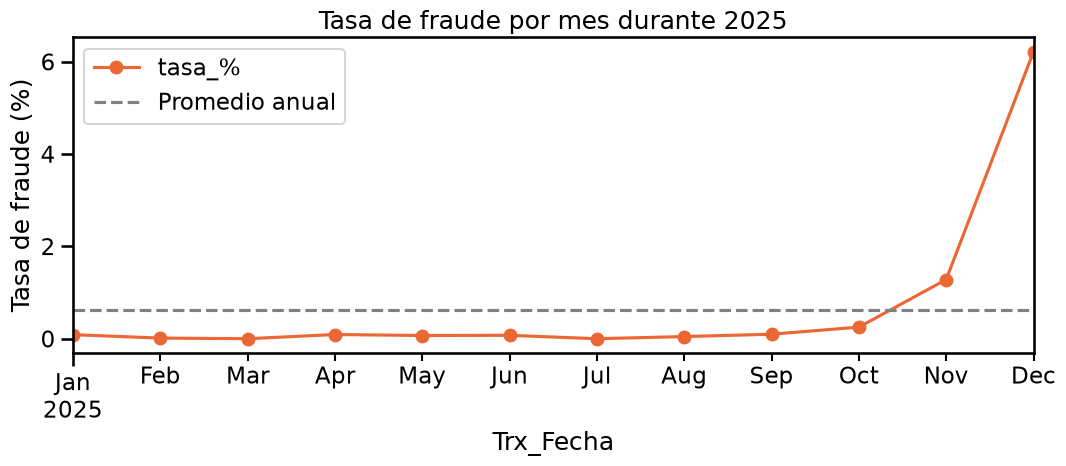

,transacciones,fraudes,tasa_%
Trx_Fecha,,,
2025-01,15854,14,0.088
2025-02,14466,2,0.014
2025-03,16034,0,0.000
2025-04,15418,14,0.091
2025-05,15854,11,0.069
2025-06,16232,12,0.074
2025-07,16620,0,0.000
2025-08,17204,8,0.047
2025-09,16426,16,0.097


In [16]:
# --- Tasa de fraude por mes: ¿aumenta o disminuye? ---
tasa_fraude_mensual = df.groupby(df['Trx_Fecha'].dt.to_period('M'))['Es_Fraude'].agg(['size', 'sum', 'mean'])
tasa_fraude_mensual.columns = ['transacciones', 'fraudes', 'tasa_%']
tasa_fraude_mensual['tasa_%'] *= 100

fig, ax = plt.subplots(figsize=(11, 5))
tasa_fraude_mensual['tasa_%'].plot(kind='line', marker='o', color=COLOR_NARANJA, ax=ax)
ax.axhline(df['Es_Fraude'].mean()*100, linestyle='--', color='gray', label='Promedio anual')
ax.set_ylabel('Tasa de fraude (%)')
ax.set_title('Tasa de fraude por mes durante 2025')
ax.legend()
plt.tight_layout()
plt.show()

tasa_fraude_mensual.round(3)

**Este es el hallazgo más importante de todo el notebook.** De enero a septiembre, la tasa de fraude se mueve siempre entre 0% y 0,1% -- prácticamente plana. En octubre empieza a subir (0,25%), en noviembre se dispara a 1,28%, y en **diciembre llega a 6,22%** -- 851 de los 1.196 fraudes de todo el año (el 71%) ocurrieron en ese único mes.

In [17]:
# ¿Es solo que en diciembre hay más transacciones en dólares (que ya sabemos que tienen más fraude),
# o la tasa de fraude sube DENTRO de cada moneda por separado?
dic = df[df['Trx_Fecha'].dt.month == 12]
resto = df[df['Trx_Fecha'].dt.month != 12]

comparacion_diciembre = pd.DataFrame({
    'Resto del año': [resto[resto.Trx_Moneda==1].Es_Fraude.mean()*100, resto[resto.Trx_Moneda==2].Es_Fraude.mean()*100],
    'Diciembre': [dic[dic.Trx_Moneda==1].Es_Fraude.mean()*100, dic[dic.Trx_Moneda==2].Es_Fraude.mean()*100],
}, index=['Tasa de fraude en Pesos (%)', 'Tasa de fraude en Dólares (%)'])
comparacion_diciembre['Aumento (veces)'] = (comparacion_diciembre['Diciembre'] / comparacion_diciembre['Resto del año']).round(1)
comparacion_diciembre.round(3)

,Resto del año,Diciembre,Aumento (veces)
Tasa de fraude en Pesos (%),0.092,3.726,40.5
Tasa de fraude en Dólares (%),3.753,36.294,9.7


**La respuesta: sube dentro de cada moneda por separado**, y mucho -- la tasa de fraude en pesos se multiplica por ~40 en diciembre, y en dólares por ~10. No es (solo) que en diciembre haya más compras en dólares (aunque también las hay, casi el triple que el resto del año, algo consistente con viajes/compras de fin de año) -- es que, en diciembre, **una transacción con las mismas características que el resto del año tiene muchas más chances de ser fraude**. Eso es lo que en Machine Learning se llama ***concept drift***: no cambió la distribución de los datos de entrada, cambió la relación entre esos datos y el resultado que se quiere predecir -- y es un tipo de drift que un chequeo como el de la sección 5.2 (que solo mira `X`) **no detecta**, justamente porque no mira `Es_Fraude`.

**Esto corrige la conclusión de la sección 5.2**: no es que "no hubo drift en 2025" -- no hubo drift *en las variables de entrada*, pero hubo un drift muy grande *en el comportamiento del fraude*, concentrado en el último bimestre del año (posiblemente asociado a mayor actividad de compras de fin de año, aunque confirmarlo con certeza requeriría información que no está en este dataset). Es exactamente el tipo de patrón que un monitoreo real necesita capturar, y por eso el punto que sigue lo pone primero en la lista.

**Una salvedad sobre el modelo entrenado en las secciones 2-4:** como el split de train/test es aleatorio por fila (no por fecha), tanto entrenamiento como evaluación contienen una mezcla proporcional de meses "tranquilos" y de diciembre -- por eso las métricas que reportamos son razonables como resumen del año completo, pero no dicen mucho sobre qué tan bien funcionaría el modelo evaluado *solo* en un mes fuera de diciembre, o en un diciembre futuro con un patrón distinto al de este año. Repetir la evaluación con una partición estrictamente temporal (entrenar con parte del año, evaluar solo con los meses más recientes) daría una medida más realista de cómo se comportaría el modelo en producción -- queda como una mejora para una futura iteración, fuera del alcance puntual de este notebook.

## 5.3 Propuesta de monitoreo y reentrenamiento

En base a lo anterior, una propuesta concreta y acotada al alcance de este proyecto:

**Qué monitorear, con qué frecuencia:**
- **La tasa de fraude real, mes a mes** -- es lo primero de la lista, y no por completitud metodológica: es exactamente lo que hubiera hecho falta para anticipar el salto de octubre-diciembre que encontramos en 5.2. Un aumento sostenido de dos meses seguidos, incluso chico, amerita revisar el modelo antes de esperar a que la precision de las alertas lo confirme.
- **Volumen de alertas** generadas por semana -- una suba o baja brusca sin una causa de negocio conocida es la segunda señal más rápida de que algo cambió.
- **Precision real de las alertas**, una vez que el equipo de analistas las resuelve -- si empieza a bajar sostenidamente, el modelo se está desactualizando.
- **Drift de las variables de entrada** (`Rubro_Categoria_TasaFraude`, `Es_Moneda_Dolar`, `Desvio_Importe_Cliente_Abs`, según la importancia que vimos en el TP3), con el mismo chequeo de la sección 5.2 (KS y Cramér's V, **mirando la magnitud, no solo el p-valor**) -- útil, pero como vimos, **no alcanza por sí solo**: no habría detectado el salto de fraude de fin de año, porque ese fue un cambio en la relación `X → Es_Fraude`, no en `X`. Por eso conviene mirarlo como complemento de la tasa de fraude, nunca como reemplazo.

Sugerimos correr los cuatro chequeos **mensualmente**.

**Cuándo reentrenar:** no ante cualquier señal aislada (como vimos, casi cualquier chequeo de p-valor "da positivo" con suficientes datos), sino cuando se cumpla alguna de estas condiciones:
- La tasa de fraude mensual se duplica (o más) respecto del promedio de los 3 meses anteriores -- el umbral concreto que, aplicado retroactivamente, hubiera encendido una alerta en octubre de este mismo dataset, antes de que noviembre y diciembre dispararan el problema.
- Más de un tercio de las variables de entrada monitoreadas muestran drift de **magnitud grande** (KS o Cramér's V ≥ 0,1) en el mismo mes.
- La precision real de las alertas cae de forma sostenida por 2 meses seguidos.
- Pasaron más de 6 meses desde el último (re)entrenamiento, como piso de seguridad aunque no se detecte nada de lo anterior.

**Cómo reentrenar:** incorporando las alertas ya resueltas por los analistas (sección 5.1) como nuevos datos etiquetados, sumadas a los datos históricos -- nunca reemplazando el histórico por completo, para no perder de vista patrones de fraude poco frecuentes que podrían no aparecer en un período corto reciente.

**Quién aprueba el modelo reentrenado:** como cualquier cambio de modelo puede alterar a gran escala qué transacciones se bloquean o revisan, un reentrenamiento no debería promoverse a producción de forma automática -- alguien del equipo tiene que comparar el modelo nuevo contra el vigente (con los mismos gráficos y métricas de este notebook) y aprobar el cambio explícitamente antes de reemplazarlo.

# Conclusiones

- **Punto 1 (fuga temporal) -- resuelto:** `Cliente_Trx_Count` y `Desvio_Importe_Cliente_Abs` ahora se calculan solo con transacciones anteriores de cada cliente. El Random Forest del TP3 sí estaba parcialmente inflado por la fuga: F1 real 0,613 contra el 0,635 reportado antes -- una caída moderada (~3,5%), no pareja entre precision (que sube) y recall (que absorbe toda la caída).
- **Punto 2 (umbral del Random Forest) -- resuelto:** el umbral óptimo (0,32) mejora el F1 a **0,645**, el mejor resultado de todo el proyecto hasta ahora -- superando otra vez, aunque por poco, al número original del TP3, a pesar de partir de datos sin fuga de información. Es la principal conclusión práctica de este notebook: **datos corregidos + umbral bien elegido > datos con fuga + umbral por defecto**.
- **Punto 3 (boosting) -- resuelto:** entrenado, ajustado, y comparado. No superó al Random Forest en esta tarea (F1 0,191 contra 0,645) -- pero ofrece un recall mucho más alto (0,87 contra 0,61) que lo deja como alternativa válida si el negocio decidiera priorizar exclusivamente no dejar pasar fraude por sobre la cantidad de falsas alarmas.
- **Punto 5 (producción) -- resuelto**, con un hallazgo que no esperábamos al empezar: un esquema de revisión humana en vez de bloqueo automático, y un chequeo real de drift que mostró dos cosas distintas -- las variables de entrada **no** cambiaron de forma relevante durante 2025 (mucho ruido de p-valor, poca magnitud real), pero la **tasa de fraude sí**, y drásticamente: se multiplicó por ~40 en pesos y ~10 en dólares durante diciembre, con el 71% de todo el fraude del año concentrado en ese único mes. Es un ejemplo real, encontrado en los propios datos del proyecto, de por qué monitorear solo las variables de entrada no alcanza -- y quedó incorporado como el primer punto de la propuesta de monitoreo.

**Punto 4 (más datos históricos) queda fuera del alcance de este notebook**, porque no depende de un análisis o modelo nuevo sino de conseguir más meses o clientes del banco -- no hay nada que programar para resolverlo con los datos que ya tenemos.

**Recomendación final del proyecto, actualizada:** Random Forest, entrenado sobre las variables de comportamiento corregidas (sección 1-2, sin `Franja_Horaria` -- ver TP2 sección 4.1) y con el umbral de decisión ajustado a 0,32 (sección 3) -- F1 = 0,645, precision = 0,682, recall = 0,611 en evaluación.
